In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from sklearn import svm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import font_manager, rc
path = "c:/Windows/Fonts/malgun.ttf"
if platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system... sorry~~~~')

In [3]:
data = pd.read_csv("C:/Users/PC/Desktop/산단공.csv", encoding = "cp949")
data.head()

,연번,시도명,관리기관,단지명,입주일,최초등록일,기준년월,노동지청,행정구역,대업종,...,요양승인일,사망승인일,근로손실일수,요양기간,근속기간,성별,연령,재해발생년도,재해발생월,재해발생일
0,164,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20180604.0,NaN,202012,서울관악,서울,기타의사업,...,20200708,NaN,147,91일 ~ 180일,1년 ~ 2년 미만,남,30세 ~ 34세,2019,12,19
1,719,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20100202.0,20210419.0,201812,서울관악,서울,기타의사업,...,20180906,NaN,221,6개월 ~ 1년미만,5년 ~ 10년 미만,남,50세 ~ 54세,2018,3,21
2,868,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,NaN,19970930.0,201912,서울관악,서울,제조업,...,20190404,NaN,113,91일 ~ 180일,4년 ~ 5년 미만,남,55세 ~ 59세,2019,1,12
3,892,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20060119.0,20060703.0,201912,서울관악,서울,제조업,...,20190122,NaN,42,29일 ~ 90일,10년 ~ 20년 미만,여,50세 ~ 54세,2018,12,12
4,898,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20140312.0,20140530.0,201812,서울관악,서울,제조업,...,20181026,NaN,149,91일 ~ 180일,1년 ~ 2년 미만,남,60세 ~ 64세,2018,10,7


In [219]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연번      19825 non-null  int64  
 1   시도명     19825 non-null  object 
 2   관리기관    19825 non-null  object 
 3   단지명     19825 non-null  object 
 4   입주일     19313 non-null  float64
 5   최초등록일   16449 non-null  float64
 6   기준년월    19825 non-null  int64  
 7   노동지청    19825 non-null  object 
 8   행정구역    19825 non-null  object 
 9   대업종     19825 non-null  object 
 10  중업종     19825 non-null  object 
 11  소업종     19825 non-null  object 
 12  근로자수    19825 non-null  int64  
 13  재해자구분   19825 non-null  object 
 14  발생형태    19825 non-null  object 
 15  직업병_대   19825 non-null  object 
 16  직업병_중   19825 non-null  object 
 17  직업병_소   19825 non-null  object 
 18  직업병_세   19825 non-null  object 
 19  직종_대    19825 non-null  object 
 20  직종_중    19825 non-null  object 
 21  직종_소    19825 non-null  object 
 22

In [220]:
data.drop(columns = ["시도명", "관리기관", "노동지청", "행정구역", "입주일", "최초등록일", "사망승인일", "재해발생날짜", "기준년월", "직업병_대", "직업병_중", "직업병_소", "직업병_세", "요양승인일"], inplace = True)
data.isnull().sum()

연번        0
단지명       0
대업종       0
중업종       0
소업종       0
근로자수      0
재해자구분     0
발생형태      0
직종_대      0
직종_중      0
직종_소      0
근로손실일수    0
요양기간      0
근속기간      0
성별        0
연령        0
재해발생년도    0
재해발생월     0
재해발생일     0
dtype: int64

In [221]:
data.head()

,연번,단지명,대업종,중업종,소업종,근로자수,재해자구분,발생형태,직종_대,직종_중,직종_소,근로손실일수,요양기간,근속기간,성별,연령,재해발생년도,재해발생월,재해발생일
0,164,서울디지털국가산업단지,기타의사업,도소매·음식·숙박업,도소매및소비자용품수리업,7,사고부상자,체육행사 등의 사고,관리자,판매 및 고객서비스 관리직,판매 및 운송 관리자,147,91일 ~ 180일,1년 ~ 2년 미만,남,30세 ~ 34세,2019,12,19
1,719,서울디지털국가산업단지,기타의사업,도소매·음식·숙박업,도소매및소비자용품수리업,7,사고부상자,체육행사 등의 사고,전문가 및 관련 종사자,경영·금융 전문가 및 관련직,기술영업 및 중개 관련종사자,221,6개월 ~ 1년미만,5년 ~ 10년 미만,남,50세 ~ 54세,2018,3,21
2,868,서울디지털국가산업단지,제조업,출판·인쇄·제본또는인쇄물가공업,인쇄업,4,사고부상자,넘어짐,장치ㆍ기계 조작 및 조립 종사자,전기 및 전자 관련 기계조작직,전기·전자 부품 및 제품 제조장치 조작원,113,91일 ~ 180일,4년 ~ 5년 미만,남,55세 ~ 59세,2019,1,12
3,892,서울디지털국가산업단지,제조업,섬유및섬유제품제조업,의복및장신품등의제조업,2,사고부상자,넘어짐,기능원 및 관련 기능 종사자,섬유·의복 및 가죽 관련 기능직,섬유 및 가죽 관련 기능 종사자,42,29일 ~ 90일,10년 ~ 20년 미만,여,50세 ~ 54세,2018,12,12
4,898,서울디지털국가산업단지,제조업,섬유및섬유제품제조업,직물업,4,사고부상자,끼임,장치ㆍ기계 조작 및 조립 종사자,섬유 및 신발 관련 기계조작직,섬유제조 및 가공기계조작원,149,91일 ~ 180일,1년 ~ 2년 미만,남,60세 ~ 64세,2018,10,7


In [222]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   연번      19825 non-null  int64 
 1   단지명     19825 non-null  object
 2   대업종     19825 non-null  object
 3   중업종     19825 non-null  object
 4   소업종     19825 non-null  object
 5   근로자수    19825 non-null  int64 
 6   재해자구분   19825 non-null  object
 7   발생형태    19825 non-null  object
 8   직종_대    19825 non-null  object
 9   직종_중    19825 non-null  object
 10  직종_소    19825 non-null  object
 11  근로손실일수  19825 non-null  int64 
 12  요양기간    19825 non-null  object
 13  근속기간    19825 non-null  object
 14  성별      19825 non-null  object
 15  연령      19825 non-null  object
 16  재해발생년도  19825 non-null  int64 
 17  재해발생월   19825 non-null  int64 
 18  재해발생일   19825 non-null  int64 
dtypes: int64(6), object(13)
memory usage: 2.9+ MB


In [22]:
data.재해발생년도.value_counts()

2020    4163
2019    4119
2018    3849
2021    3555
2017    3268
2016     651
2015      91
2014      37
2012      14
2013      12
2009      10
2004       7
2008       6
2010       6
2005       5
2006       5
2001       4
2007       3
2002       3
1998       3
2011       2
1988       2
1993       2
2000       2
1991       1
1995       1
1984       1
2003       1
1999       1
1989       1
Name: 재해발생년도, dtype: int64

In [8]:
data['기업규모'] = 0
data.loc[data['근로자수'] >= 5, '기업규모'] = 1
data.loc[data['근로자수'] >= 50, '기업규모'] = 2
data.loc[data['근로자수'] >= 100, '기업규모'] = 3
data.loc[data['근로자수'] >= 300, '기업규모'] = 4
data.loc[data['근로자수'] >= 1000, '기업규모'] = 5
data.drop(columns = ["근로자수"], inplace = True)
data.head()

,연번,시도명,관리기관,단지명,입주일,최초등록일,기준년월,노동지청,행정구역,대업종,...,사망승인일,근로손실일수,요양기간,근속기간,성별,연령,재해발생년도,재해발생월,재해발생일,기업규모
0,164,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20180604.0,NaN,202012,서울관악,서울,기타의사업,...,NaN,147,91일 ~ 180일,1년 ~ 2년 미만,남,30세 ~ 34세,2019,12,19,1
1,719,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20100202.0,20210419.0,201812,서울관악,서울,기타의사업,...,NaN,221,6개월 ~ 1년미만,5년 ~ 10년 미만,남,50세 ~ 54세,2018,3,21,1
2,868,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,NaN,19970930.0,201912,서울관악,서울,제조업,...,NaN,113,91일 ~ 180일,4년 ~ 5년 미만,남,55세 ~ 59세,2019,1,12,0
3,892,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20060119.0,20060703.0,201912,서울관악,서울,제조업,...,NaN,42,29일 ~ 90일,10년 ~ 20년 미만,여,50세 ~ 54세,2018,12,12,0
4,898,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20140312.0,20140530.0,201812,서울관악,서울,제조업,...,NaN,149,91일 ~ 180일,1년 ~ 2년 미만,남,60세 ~ 64세,2018,10,7,0


In [5]:
pd.crosstab(data['단지명'], data['발생형태'], margins = True)

발생형태,감전,기타,깔림·뒤집힘,끼임,넘어짐,동물상해,떨어짐,무너짐,물체에 맞음,부딪힘,...,작업관련질병(뇌심 등),절단·베임·찔림,직업병(진폐 제외),진폐,체육행사 등의 사고,폭력행위,폭발·파열,화재,화학물질누출·접촉,All
단지명,,,,,,,,,,,,,,,,,,,,,
광양국가산업단지,2,0,0,27,11,0,11,0,14,12,...,22,2,22,2,20,0,6,1,0,168
광주첨단과학국가산업단지,0,0,1,5,5,0,14,0,11,2,...,8,5,1,0,0,0,0,0,0,54
구미국가산업단지,6,0,12,159,67,0,47,0,46,45,...,64,48,15,12,18,0,0,5,13,601
구미외국인투자지역,0,0,0,6,3,0,1,0,0,1,...,6,0,0,0,1,0,6,0,0,25
국가식품클러스터국가산업단지,0,0,0,8,6,0,2,0,3,1,...,3,5,0,0,2,0,0,0,0,34
군산2국가산업단지,3,0,7,85,20,0,26,1,25,25,...,18,17,6,0,1,0,5,3,3,265
군산국가산업단지,0,0,2,44,28,0,13,1,16,26,...,58,9,2,0,8,0,0,1,1,229
김해GoldenRoot일반산업단지,1,0,4,49,16,0,5,0,7,12,...,16,7,0,0,1,0,0,0,0,124
남동국가산업단지,11,2,63,579,204,1,131,3,197,133,...,171,175,27,2,4,3,9,11,15,1850


In [6]:
pd.crosstab(data.재해발생월, data.발생형태, margins = True)

발생형태,감전,기타,깔림·뒤집힘,끼임,넘어짐,동물상해,떨어짐,무너짐,물체에 맞음,부딪힘,...,작업관련질병(뇌심 등),절단·베임·찔림,직업병(진폐 제외),진폐,체육행사 등의 사고,폭력행위,폭발·파열,화재,화학물질누출·접촉,All
재해발생월,,,,,,,,,,,,,,,,,,,,,
1,5,2,24,376,188,0,69,4,92,101,...,302,60,137,7,10,0,10,9,12,1543
2,3,1,32,323,148,1,91,2,120,113,...,271,89,125,4,8,3,6,1,12,1447
3,3,0,38,398,175,0,120,4,102,113,...,375,104,135,2,17,2,4,3,12,1746
4,3,0,38,352,182,0,109,1,120,143,...,354,80,118,3,35,7,8,4,14,1707
5,3,0,29,385,149,0,86,2,119,129,...,337,99,149,7,42,6,4,4,17,1696
6,6,0,30,391,151,0,116,4,121,128,...,312,106,145,2,38,5,9,5,12,1724
7,9,0,30,422,146,0,112,5,132,134,...,353,120,134,4,15,5,7,3,16,1814
8,7,0,47,354,136,1,93,3,129,149,...,271,116,137,1,8,2,7,8,14,1613
9,8,0,29,357,154,1,89,2,125,112,...,236,85,110,4,14,1,6,9,13,1493


In [9]:
pd.crosstab(data.기업규모, data.발생형태, margins = True)

발생형태,감전,기타,깔림·뒤집힘,끼임,넘어짐,동물상해,떨어짐,무너짐,물체에 맞음,부딪힘,...,작업관련질병(뇌심 등),절단·베임·찔림,직업병(진폐 제외),진폐,체육행사 등의 사고,폭력행위,폭발·파열,화재,화학물질누출·접촉,All
기업규모,,,,,,,,,,,,,,,,,,,,,
0,9,0,40,449,146,0,180,2,217,145,...,118,185,24,3,7,1,10,5,19,1643
1,28,4,218,2155,708,3,521,23,719,575,...,677,661,101,6,72,13,42,25,77,7086
2,7,0,40,542,233,0,137,5,121,155,...,260,90,40,2,39,7,15,5,19,1879
3,15,1,26,551,266,1,138,5,118,184,...,415,89,57,3,39,9,7,13,26,2181
4,3,0,18,269,149,0,63,4,74,100,...,400,46,48,14,18,1,9,5,14,1385
5,13,0,43,532,418,1,160,0,179,365,...,1843,64,1318,21,99,9,4,4,7,5651
All,75,5,385,4498,1920,5,1199,39,1428,1524,...,3713,1135,1588,49,274,40,87,57,162,19825


In [18]:
pd.crosstab(data.소업종, data.발생형태, margins = True)

발생형태,감전,기타,깔림·뒤집힘,끼임,넘어짐,동물상해,떨어짐,무너짐,물체에 맞음,부딪힘,...,작업관련질병(뇌심 등),절단·베임·찔림,직업병(진폐 제외),진폐,체육행사 등의 사고,폭력행위,폭발·파열,화재,화학물질누출·접촉,All
소업종,,,,,,,,,,,,,,,,,,,,,
가스업,0,0,1,3,1,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,9
"가정용,사무용,서비스용기계기구제조업",0,0,1,13,2,0,7,0,4,2,...,7,8,0,0,0,0,0,0,0,45
각급사무소,0,0,1,5,4,0,2,0,1,5,...,5,3,1,0,11,0,0,0,1,41
각종금속의용접또는용단을행하는사업,2,0,12,98,30,0,21,3,45,27,...,16,36,3,0,1,0,1,1,2,319
각종기계또는동부속품제조업,4,0,34,372,74,0,65,1,160,92,...,121,78,22,2,10,0,4,2,1,1090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
해외파견자,0,0,2,2,2,0,1,0,0,2,...,3,0,3,0,0,0,0,0,1,17
화장품및향료제조업,1,0,0,28,18,0,4,0,3,9,...,12,5,0,0,1,0,0,0,1,99
화학비료제조업,0,0,1,5,2,0,4,0,0,1,...,4,0,1,0,3,0,0,0,2,28


In [11]:
pd.crosstab(data.근속기간, data.발생형태, margins = True)

발생형태,감전,기타,깔림·뒤집힘,끼임,넘어짐,동물상해,떨어짐,무너짐,물체에 맞음,부딪힘,...,작업관련질병(뇌심 등),절단·베임·찔림,직업병(진폐 제외),진폐,체육행사 등의 사고,폭력행위,폭발·파열,화재,화학물질누출·접촉,All
근속기간,,,,,,,,,,,,,,,,,,,,,
10년 ~ 20년 미만,10,0,34,443,245,0,139,1,158,198,...,792,75,96,5,33,5,15,5,16,2509
1개월 ~ 2개월 미만,3,1,19,203,70,1,54,4,63,60,...,39,63,5,1,7,1,1,2,10,662
1개월 미만,5,0,48,437,183,0,205,3,160,149,...,62,172,14,2,7,0,9,5,18,1558
1년 ~ 2년 미만,6,1,39,597,202,1,101,2,197,155,...,206,163,20,0,27,5,10,10,19,1940
20년 이상,12,0,26,405,257,1,125,0,116,219,...,1418,49,1322,34,59,9,8,4,9,4353
2개월 ~ 3개월 미만,5,0,19,134,44,0,49,3,54,48,...,37,49,1,0,7,1,0,1,10,508
2년 ~ 3년 미만,5,0,29,434,154,0,88,4,118,93,...,160,100,21,0,15,3,9,6,17,1376
3개월 ~ 4개월 미만,2,0,20,143,42,0,28,1,50,26,...,39,36,6,0,9,1,3,0,5,445
3년 ~ 4년 미만,4,1,23,235,106,0,73,2,77,81,...,146,66,12,1,14,3,4,1,8,950


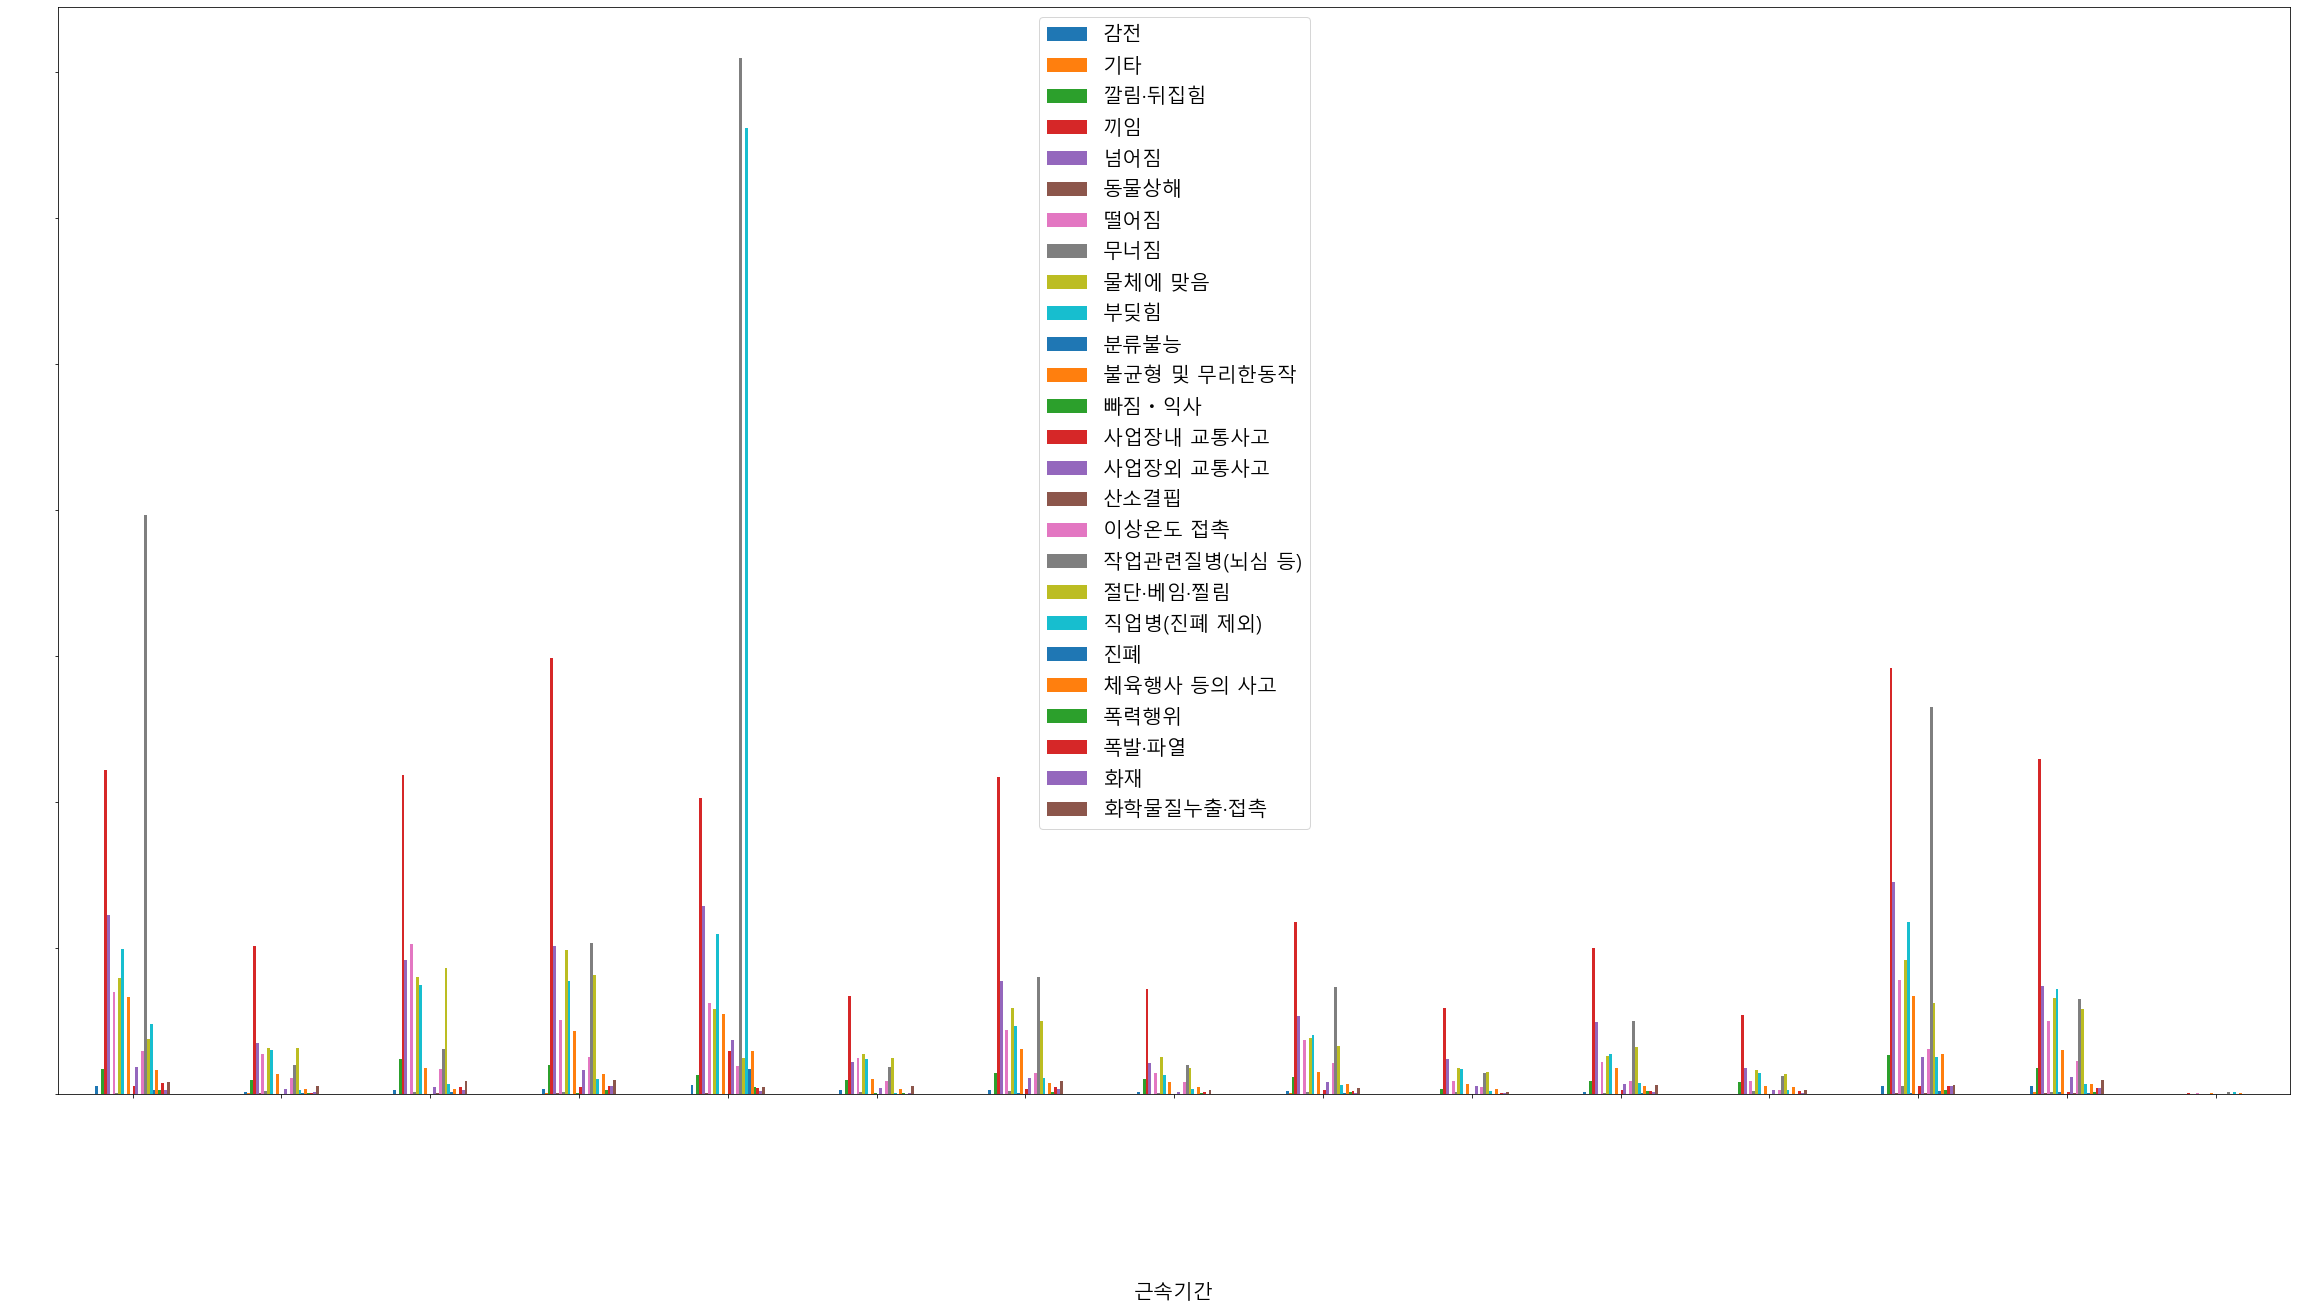

In [21]:
pd.crosstab(data.근속기간, data.발생형태).plot(kind = "bar", figsize = (40, 20))
plt.rc('font', size=20)
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')
plt.legend(loc = "best")

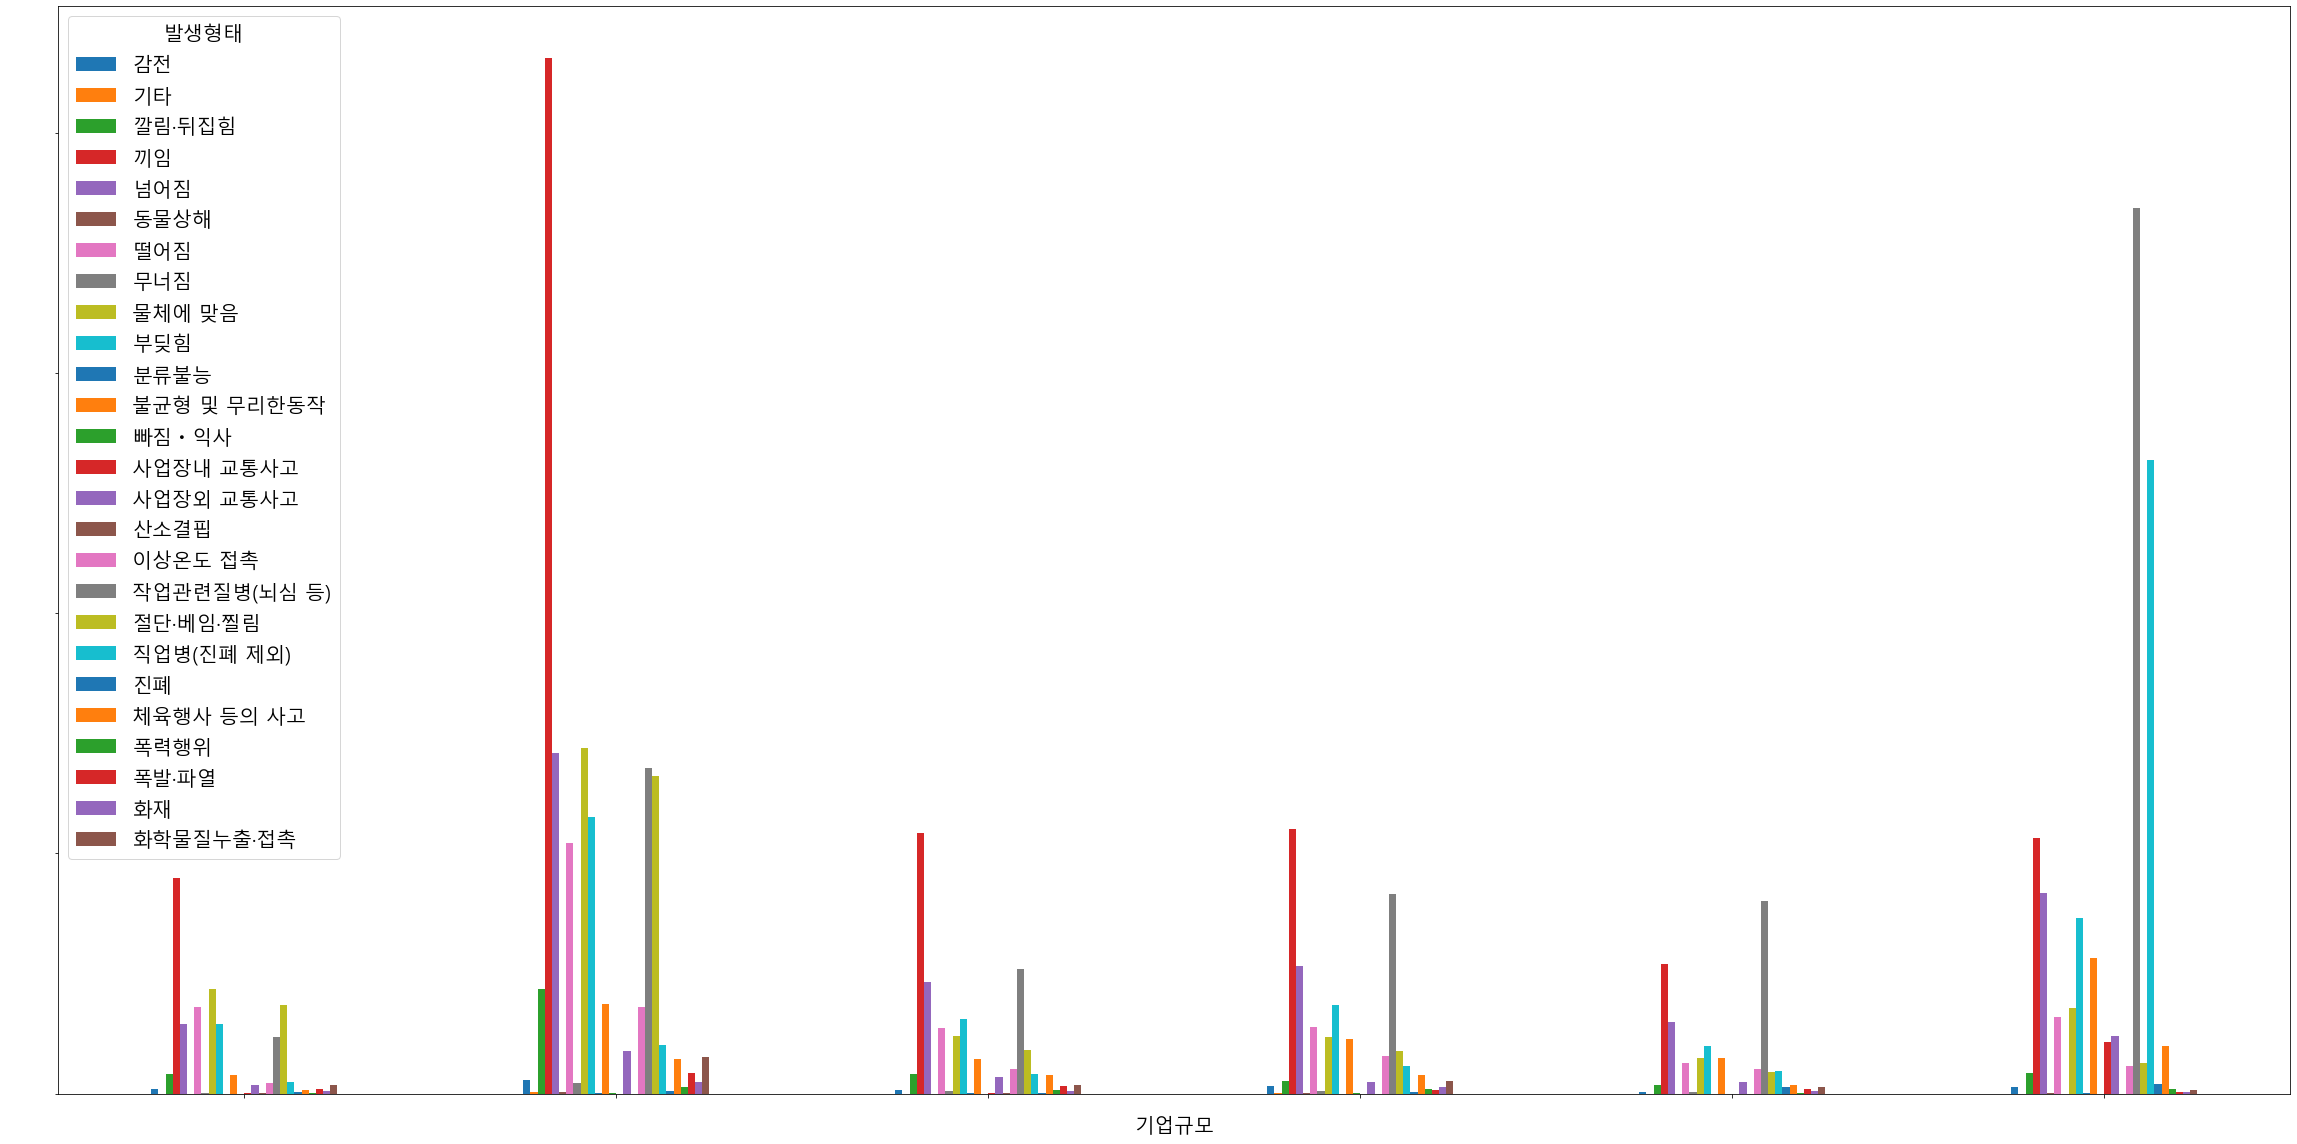

In [230]:
pd.crosstab(data['기업규모'], data['발생형태']).plot(kind = "bar", figsize = (40, 20))
plt.rc('font', size=50)
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

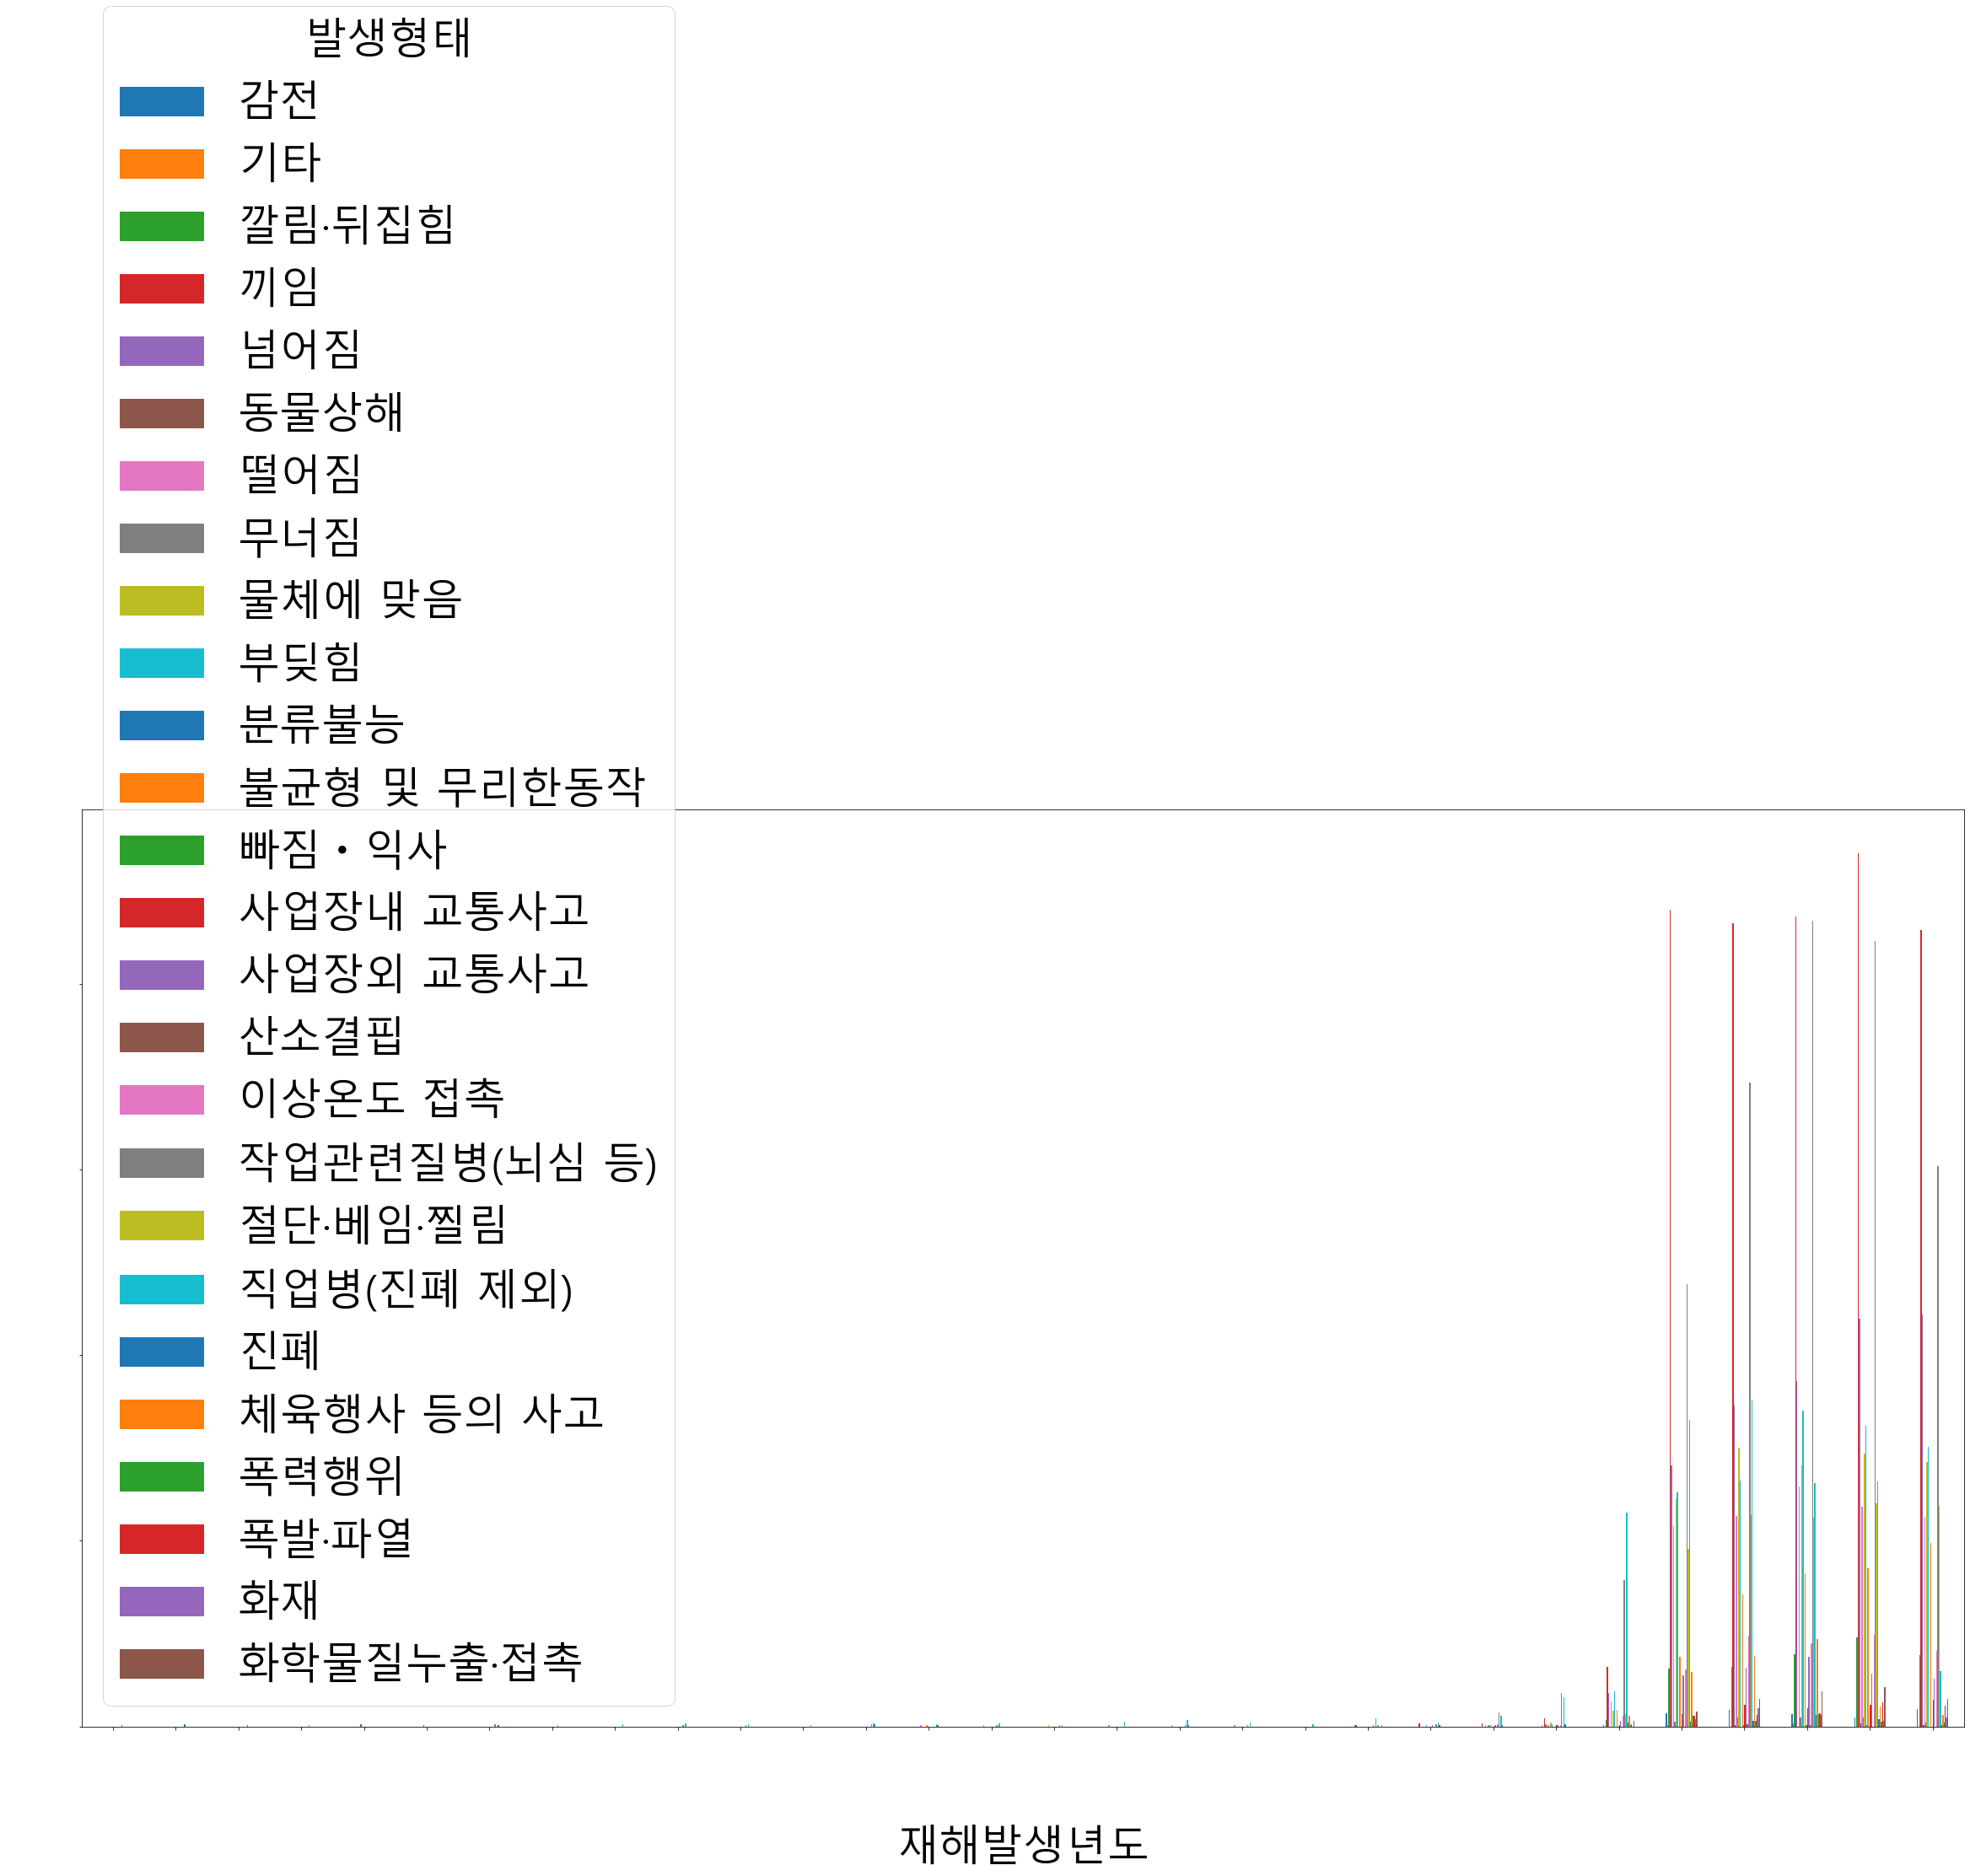

In [232]:
pd.crosstab(data['재해발생년도'], data['발생형태']).plot(kind = "bar", figsize = (40, 20))
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

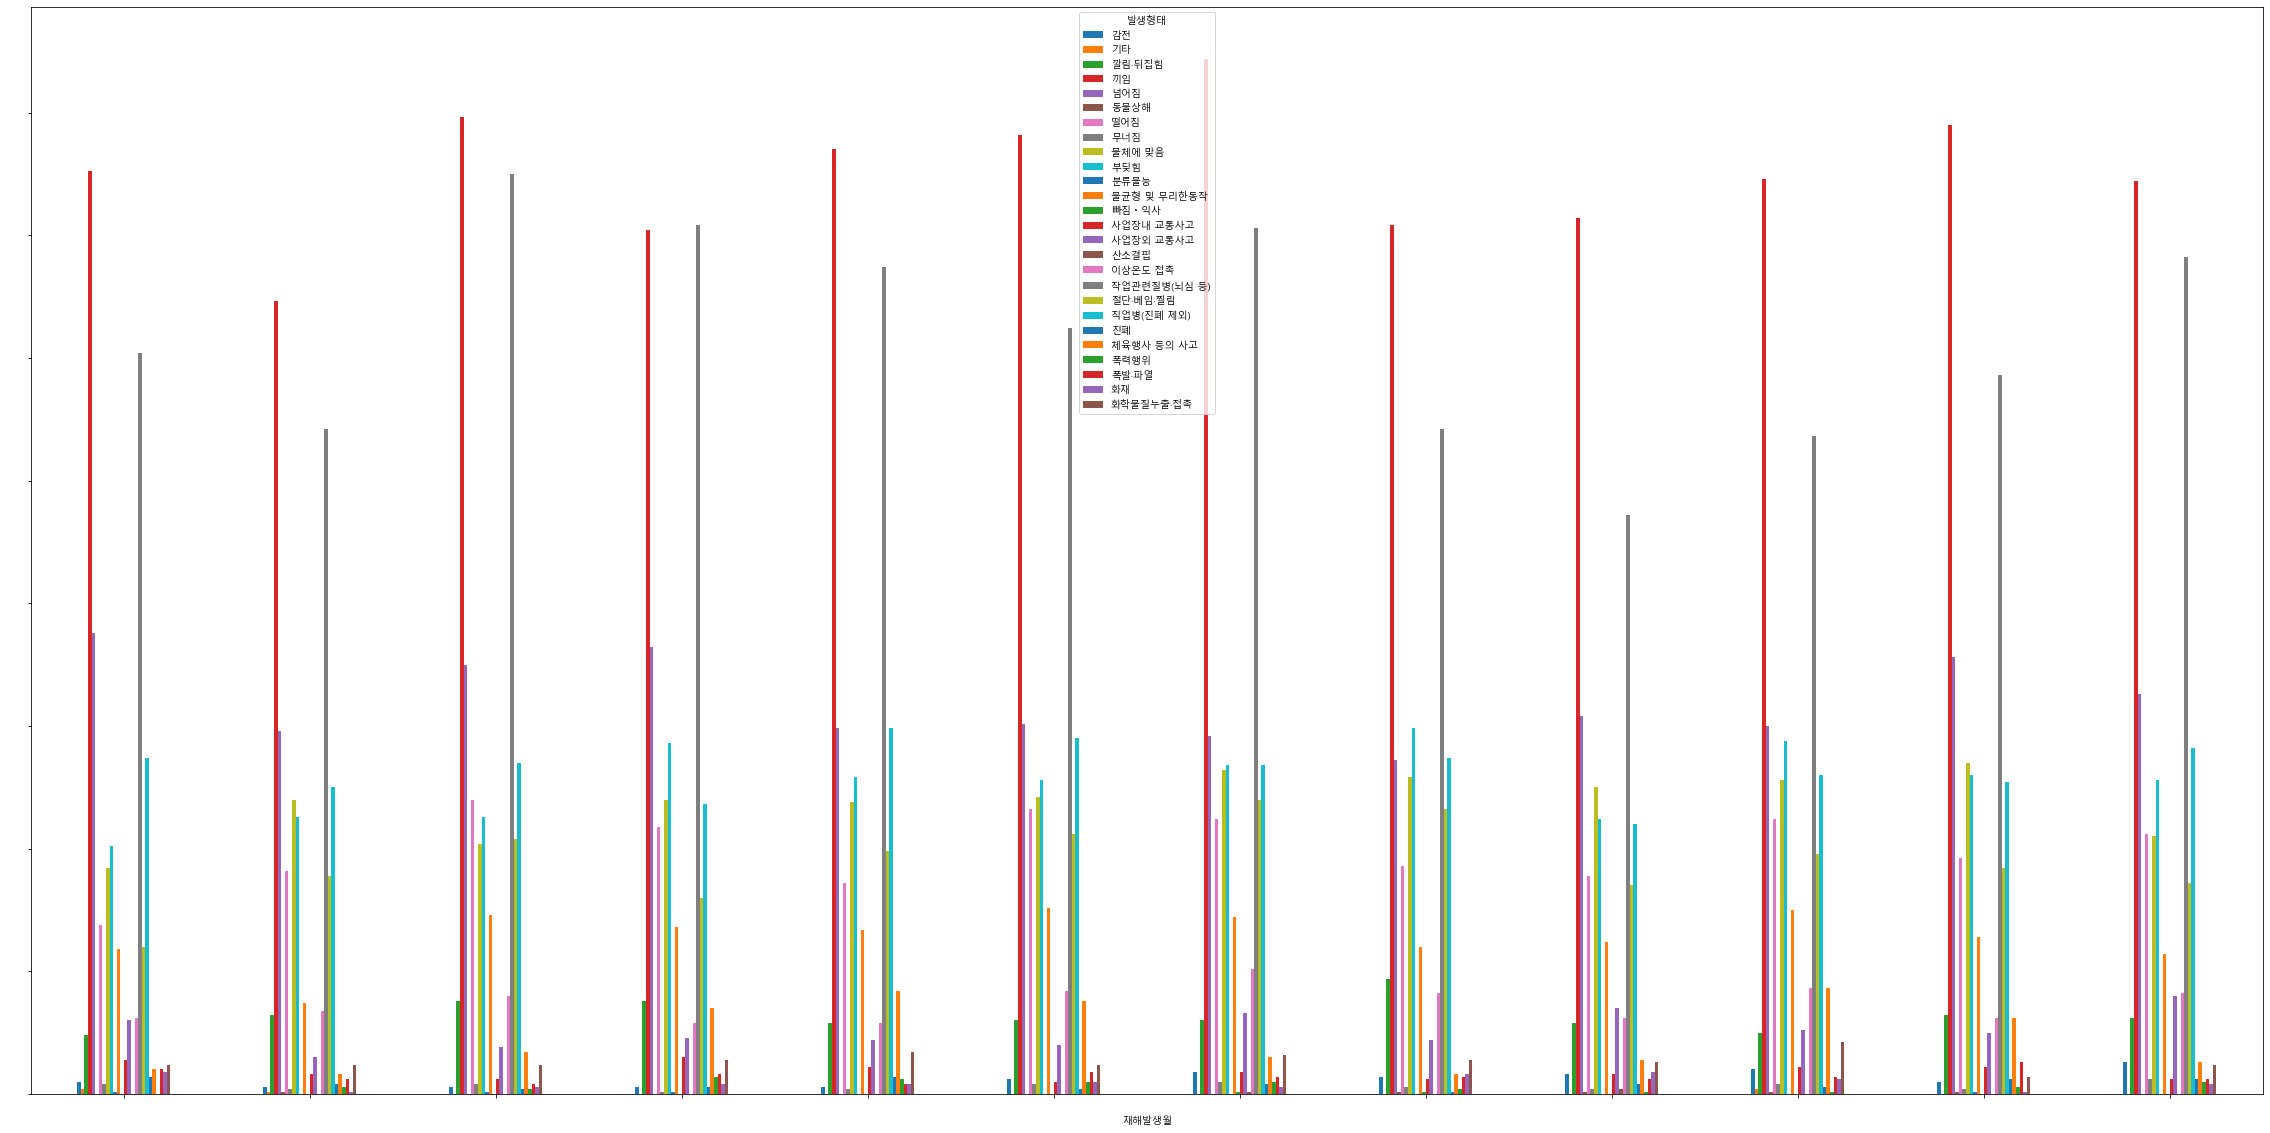

In [171]:
pd.crosstab(data['재해발생월'], data['발생형태']).plot(kind = "bar", figsize = (40, 20))
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

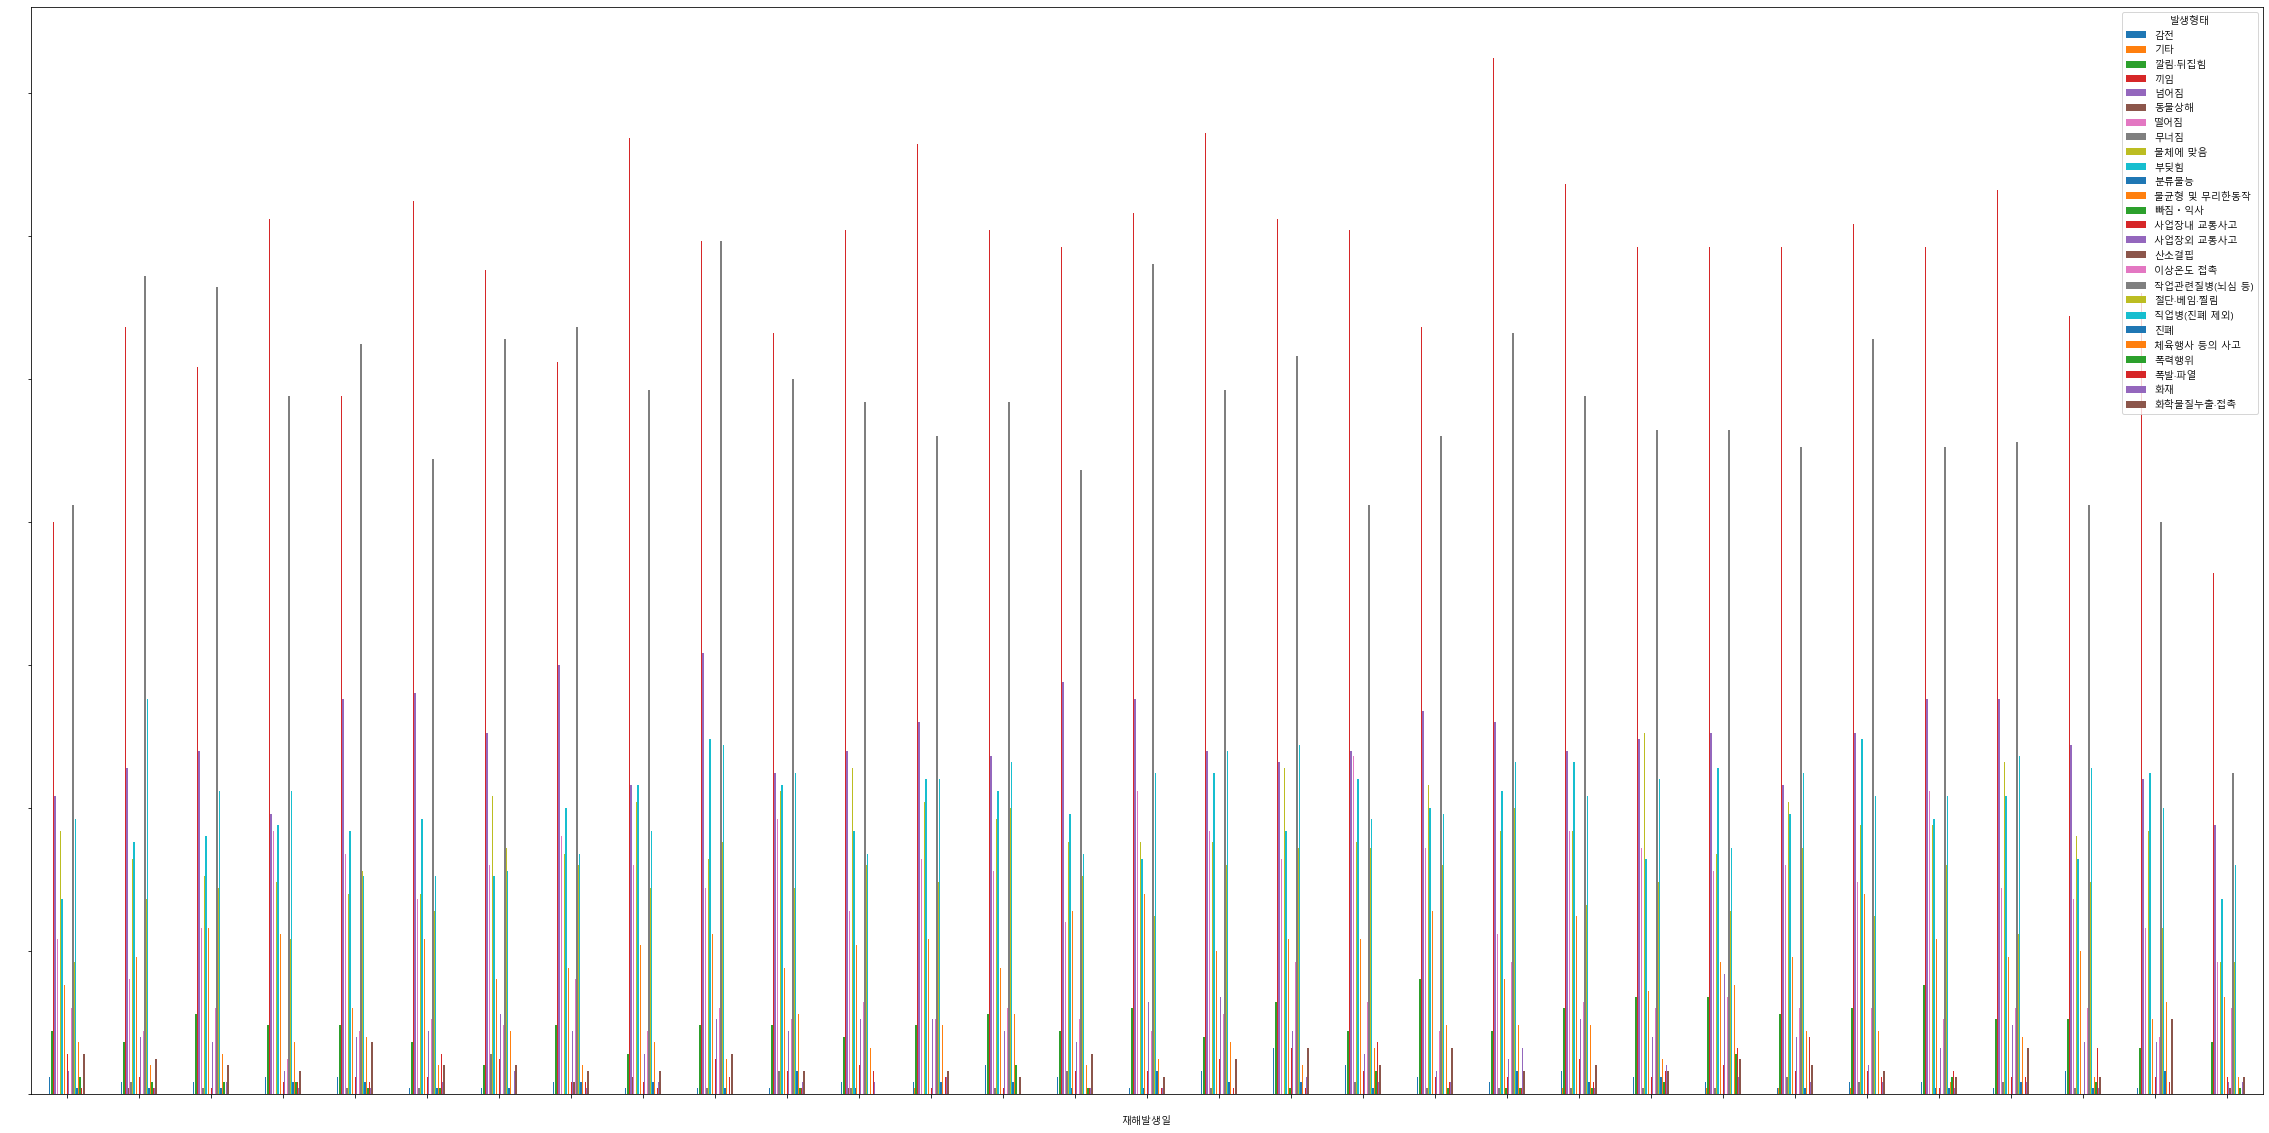

In [172]:
pd.crosstab(data['재해발생일'], data['발생형태']).plot(kind = "bar", figsize = (40, 20))
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

In [173]:
en_list = data.dtypes[(data.dtypes=='object')].index
for i in en_list:
  encoder = LabelEncoder()
  encoder.fit(data[i])
  data[i] = encoder.transform(data[i])
data.head()

,연번,단지명,대업종,중업종,소업종,재해자구분,발생형태,직종_대,직종_중,직종_소,근로손실일수,요양기간,근속기간,성별,연령,재해발생년도,재해발생월,재해발생일,기업규모
0,164,25,2,7,54,1,21,1,50,122,147,7,3,0,2,2019,12,19,1
1,719,25,2,7,54,1,21,9,8,32,221,5,12,0,6,2018,3,21,1
2,868,25,6,21,114,1,4,8,43,105,113,7,10,0,7,2019,1,12,0
3,892,25,6,11,111,1,4,2,32,69,42,2,0,1,6,2018,12,12,0
4,898,25,6,11,141,1,3,8,31,70,149,7,3,0,8,2018,10,7,0


In [174]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   연번      19825 non-null  int64
 1   단지명     19825 non-null  int32
 2   대업종     19825 non-null  int32
 3   중업종     19825 non-null  int32
 4   소업종     19825 non-null  int32
 5   재해자구분   19825 non-null  int32
 6   발생형태    19825 non-null  int32
 7   직종_대    19825 non-null  int32
 8   직종_중    19825 non-null  int32
 9   직종_소    19825 non-null  int32
 10  근로손실일수  19825 non-null  int64
 11  요양기간    19825 non-null  int32
 12  근속기간    19825 non-null  int32
 13  성별      19825 non-null  int32
 14  연령      19825 non-null  int32
 15  재해발생년도  19825 non-null  int64
 16  재해발생월   19825 non-null  int64
 17  재해발생일   19825 non-null  int64
 18  기업규모    19825 non-null  int64
dtypes: int32(13), int64(6)
memory usage: 1.9 MB


In [175]:
data = data.astype("object")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   연번      19825 non-null  object
 1   단지명     19825 non-null  object
 2   대업종     19825 non-null  object
 3   중업종     19825 non-null  object
 4   소업종     19825 non-null  object
 5   재해자구분   19825 non-null  object
 6   발생형태    19825 non-null  object
 7   직종_대    19825 non-null  object
 8   직종_중    19825 non-null  object
 9   직종_소    19825 non-null  object
 10  근로손실일수  19825 non-null  object
 11  요양기간    19825 non-null  object
 12  근속기간    19825 non-null  object
 13  성별      19825 non-null  object
 14  연령      19825 non-null  object
 15  재해발생년도  19825 non-null  object
 16  재해발생월   19825 non-null  object
 17  재해발생일   19825 non-null  object
 18  기업규모    19825 non-null  object
dtypes: object(19)
memory usage: 2.9+ MB


In [176]:
data.근로손실일수 = data.근로손실일수.astype("int")
data.발생형태 = data.발생형태.astype("int")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   연번      19825 non-null  object
 1   단지명     19825 non-null  object
 2   대업종     19825 non-null  object
 3   중업종     19825 non-null  object
 4   소업종     19825 non-null  object
 5   재해자구분   19825 non-null  object
 6   발생형태    19825 non-null  int32 
 7   직종_대    19825 non-null  object
 8   직종_중    19825 non-null  object
 9   직종_소    19825 non-null  object
 10  근로손실일수  19825 non-null  int32 
 11  요양기간    19825 non-null  object
 12  근속기간    19825 non-null  object
 13  성별      19825 non-null  object
 14  연령      19825 non-null  object
 15  재해발생년도  19825 non-null  object
 16  재해발생월   19825 non-null  object
 17  재해발생일   19825 non-null  object
 18  기업규모    19825 non-null  object
dtypes: int32(2), object(17)
memory usage: 2.7+ MB


In [177]:
X = data.drop(columns = ["발생형태"])
y = data[["발생형태"]]

In [178]:
X.head()

,연번,단지명,대업종,중업종,소업종,재해자구분,직종_대,직종_중,직종_소,근로손실일수,요양기간,근속기간,성별,연령,재해발생년도,재해발생월,재해발생일,기업규모
0,164,25,2,7,54,1,1,50,122,147,7,3,0,2,2019,12,19,1
1,719,25,2,7,54,1,9,8,32,221,5,12,0,6,2018,3,21,1
2,868,25,6,21,114,1,8,43,105,113,7,10,0,7,2019,1,12,0
3,892,25,6,11,111,1,2,32,69,42,2,0,1,6,2018,12,12,0
4,898,25,6,11,141,1,8,31,70,149,7,3,0,8,2018,10,7,0


In [179]:
y.head()

,발생형태
0,21
1,21
2,4
3,4
4,3


In [196]:
#from sklearn.tree import export_graphviz

#export_graphviz(model, out_file = "tree.dot", impurity = True, filled = True)

In [197]:
#import graphviz

#with open("tree.dot") as f:
  #dot_graph = f.read()
#graphviz.Source(dot_graph)